<a href="https://colab.research.google.com/github/zubaeteee20210205109-droid/Trial/blob/main/MobileNET_HA_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import random
random.seed(0)

import numpy as np
np.random.seed(0)

import tensorflow as tf
tf.random.set_seed(0)

In [35]:
import os
import json
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.utils.class_weight import compute_class_weight
from collections import Counter

In [4]:
base_dir = '/content/drive/MyDrive/dataset/Augmented'
print("Classes:", os.listdir(base_dir))

Classes: ['infected', 'not_infected']


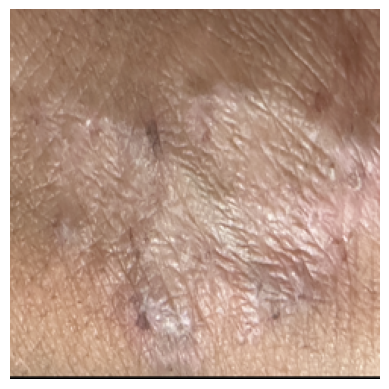

In [6]:
image_path = '/content/IMG_2006_augmented_4.png'
img = mpimg.imread(image_path)
plt.imshow(img)
plt.axis('off')
plt.show()

In [8]:
img_size = 224
batch_size = 32
epochs_initial = 10
epochs_finetune = 10

In [37]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True
)

In [10]:
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

In [11]:
train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset='training',
    class_mode='categorical'
)

Found 7116 images belonging to 2 classes.


In [12]:
validation_generator = val_datagen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset='validation',
    class_mode='categorical'
)

Found 1778 images belonging to 2 classes.


In [38]:
print("Training class distribution:", Counter(train_generator.classes))

Training class distribution: Counter({np.int32(0): 3559, np.int32(1): 3557})


In [13]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(0.9997190221972464), 1: np.float64(1.000281135788586)}


In [14]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(img_size, img_size, 3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [15]:
base_model.trainable = False

In [16]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

In [17]:
output = Dense(train_generator.num_classes, activation='softmax')(x)

In [18]:
model = Model(inputs=base_model.input, outputs=output)

In [19]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,619,074 (9.99 MB)

 Trainable params: 361,090 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [21]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [22]:
history = model.fit(
    train_generator,
    epochs=epochs_initial,
    validation_data=validation_generator,
    class_weight=class_weights,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 2619s 12s/step - accuracy: 0.6549 - loss: 0.7005 - val_accuracy: 0.7469 - val_loss: 0.5226
Epoch 2/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 405s 2s/step - accuracy: 0.8662 - loss: 0.3202 - val_accuracy: 0.7688 - val_loss: 0.4919
Epoch 3/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 349s 2s/step - accuracy: 0.9139 - loss: 0.2210 - val_accuracy: 0.7773 - val_loss: 0.5186
Epoch 4/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 303s 1s/step - accuracy: 0.9277 - loss: 0.1919 - val_accuracy: 0.7846 - val_loss: 0.5301
Epoch 5/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 309s 1s/step - accuracy: 0.9407 - loss: 0.1526 - val_accuracy: 0.7745 - val_loss: 0.5901
Epoch 6/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 295s 1s/step - accuracy: 0.9496 - loss: 0.1380 - val_accuracy: 0.8020 - val_loss: 0.5092
Epoch 7/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 314s 1s/step - accuracy: 0.9532 - loss: 0.1207 - val_accuracy: 0.8003 - val_loss: 0.5667


In [23]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

In [24]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:
history_finetune = model.fit(
    train_generator,
    epochs=epochs_finetune,
    validation_data=validation_generator,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 463s 2s/step - accuracy: 0.8091 - loss: 0.4113 - val_accuracy: 0.7913 - val_loss: 0.5681
Epoch 2/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 436s 2s/step - accuracy: 0.9050 - loss: 0.2328 - val_accuracy: 0.8076 - val_loss: 0.5410
Epoch 3/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 464s 2s/step - accuracy: 0.9268 - loss: 0.1753 - val_accuracy: 0.8375 - val_loss: 0.4701
Epoch 4/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 490s 2s/step - accuracy: 0.9509 - loss: 0.1365 - val_accuracy: 0.8459 - val_loss: 0.4806
Epoch 5/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 399s 2s/step - accuracy: 0.9552 - loss: 0.1189 - val_accuracy: 0.8678 - val_loss: 0.4107
Epoch 6/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 411s 2s/step - accuracy: 0.9609 - loss: 0.1139 - val_accuracy: 0.8712 - val_loss: 0.4247
Epoch 7/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 407s 2s/step - accuracy: 0.9690 - loss: 0.0835 - val_accuracy: 0.8718 - val_loss: 0.4248
Epoch 8/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 424s 2s/step - accuracy: 0.9737 - loss: 0.0792 - val_accu

In [39]:
val_loss, val_accuracy = model.evaluate(validation_generator)
print(f"Final Validation Accuracy: {val_accuracy * 100:.2f}%")

56/56 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.8667 - loss: 0.4016
Final Validation Accuracy: 87.18%


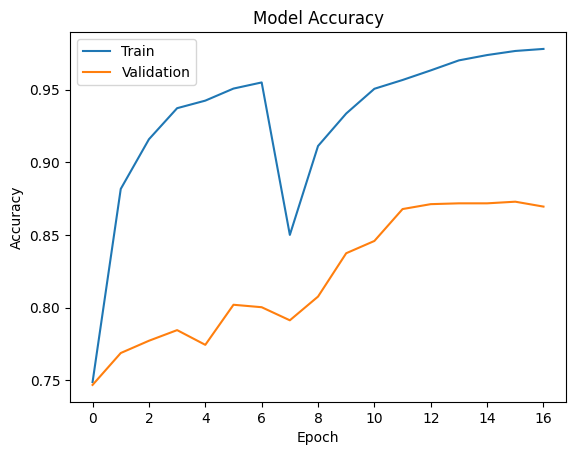

In [27]:
plt.plot(history.history['accuracy'] + history_finetune.history['accuracy'])
plt.plot(history.history['val_accuracy'] + history_finetune.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

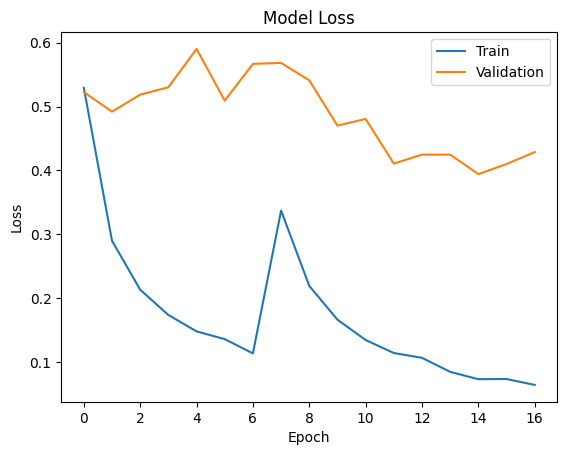

In [28]:
plt.plot(history.history['loss'] + history_finetune.history['loss'])
plt.plot(history.history['val_loss'] + history_finetune.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

In [40]:
def load_and_preprocess_image(image_path, target_size=(224, 224)):
    img = Image.open(image_path).convert('RGB')
    img = img.resize(target_size)
    img = np.array(img)
    img = preprocess_input(img)
    img = np.expand_dims(img, axis=0)
    return img

In [41]:
def predict_image_class(model, image_path, class_indices):
    img = load_and_preprocess_image(image_path)
    pred = model.predict(img)
    class_id = np.argmax(pred, axis=1)[0]
    return class_indices[class_id]

In [42]:
class_indices = {v: k for k, v in train_generator.class_indices.items()}
json.dump(class_indices, open('class_indices.json', 'w'))
print("Class Indices:", class_indices)

Class Indices: {0: 'infected', 1: 'not_infected'}


In [44]:
test_image = '/content/IMG_1169_augmented_4.png'
print("Predicted Class:", predict_image_class(model, test_image, class_indices))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Predicted Class: infected
